# Historical Backcast Generation for RL Training (2019-2023)

**Purpose:** Train models on 2002-2018 data, forecast 2019-2023 for RL agent training

**Variables:** Temperature AND ET0 (both needed for dual-variable RL agent)

**Models (EXACT parameters from unified_forecast.ipynb):**
- ✨ **Prophet** - Multiplicative seasonality
- 🔧 **SARIMA** - auto_arima with max_p=5, max_q=5
- 🧠 **LSTM** - Bidirectional(LSTM(64)) + Bidirectional(LSTM(32)) + Dropout
- 📈 **Ridge** - Polynomial degree=2, alpha=1.0

**Outputs:**
- `historical_backcasts_temperature_2019_2023_real.csv`
- `historical_backcasts_et0_2019_2023_real.csv`

## 🔧 Environment Setup (Colab Compatible)

In [1]:
# Detect environment
import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("🌐 Running in Google Colab")
    print("📥 Installing required packages...")
    !pip install -q pmdarima statsmodels prophet scikit-learn
    print("✅ Packages installed!")
else:
    print("💻 Running locally")

🌐 Running in Google Colab
📥 Installing required packages...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 18.7 MB/s eta 0:00:00
✅ Packages installed!


## 📥 Data Download (Automatic from Google Drive)

In [2]:
import os

if IN_COLAB:
    print("📥 Downloading data from Google Drive...")
    file_id = "1TnlYsNUJq7--Kgj9AWGmhMAiW1N4ExbW"

    !pip install -q gdown
    import gdown

    url = f"https://drive.google.com/uc?id={file_id}"
    output = "algiers_monthly_processed_v2.csv"
    gdown.download(url, output, quiet=False)

    data_path = output
    print(f"✅ Data downloaded to: {data_path}")
else:
    from pathlib import Path
    data_path = Path('../Preprocessed_dataset/algiers_monthly_processed_v2.csv')
    print(f"💻 Using local data: {data_path}")

📥 Downloading data from Google Drive...


Downloading...
From: https://drive.google.com/uc?id=1TnlYsNUJq7--Kgj9AWGmhMAiW1N4ExbW
To: /content/algiers_monthly_processed_v2.csv
100%|██████████| 60.8k/60.8k [00:00<00:00, 15.1MB/s]

✅ Data downloaded to: algiers_monthly_processed_v2.csv


## 1. Library Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from pmdarima import auto_arima
from prophet import Prophet

from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler

from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


## 2. Load and Split Data

- **Training:** 2002-2018 (204 months)
- **Testing:** 2019-2023 (56 months)
- **Variables:** Temperature AND ET0

In [4]:
df = pd.read_csv(data_path)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print(f"📊 Total data: {len(df)} months ({df['date'].min().date()} to {df['date'].max().date()})\n")

split_date = '2019-01-01'
train_df = df[df['date'] < split_date].copy()
test_df = df[(df['date'] >= split_date) & (df['date'] < '2024-01-01')].copy()

print(f"🎯 Training: {len(train_df)} months ({train_df['date'].min().date()} to {train_df['date'].max().date()})")
print(f"🎯 Testing:  {len(test_df)} months ({test_df['date'].min().date()} to {test_df['date'].max().date()})\n")

test_dates = test_df['date'].values
n_forecast = len(test_df)

print(f"✅ Will forecast {n_forecast} months for BOTH temperature and ET0")

📊 Total data: 260 months (2002-01-01 to 2023-08-01)

🎯 Training: 204 months (2002-01-01 to 2018-12-01)
🎯 Testing:  56 months (2019-01-01 to 2023-08-01)

✅ Will forecast 56 months for BOTH temperature and ET0


## 3. Define Model Training Function (Works for Both Variables)

In [5]:
def train_all_models(train_data, test_actual, variable_name, n_forecast):
    """
    Train all 4 models for a given variable
    Returns forecasts for SARIMA, LSTM, Ridge, Prophet
    """
    print(f"\n{'='*70}")
    print(f"🌡️  TRAINING MODELS FOR: {variable_name.upper()}")
    print(f"{'='*70}\n")

    # 1. SARIMA
    print("🔧 Training Enhanced SARIMA...")
    sarima_model = auto_arima(
        train_data,
        seasonal=True, m=12,
        max_p=5, max_q=5,
        max_P=3, max_Q=3,
        information_criterion='aic',
        trace=False,
        error_action='ignore',
        suppress_warnings=True,
        stepwise=True
    )
    sarima_forecast = sarima_model.predict(n_periods=n_forecast)
    sarima_mae = mean_absolute_error(test_actual, sarima_forecast)
    print(f"   ✅ SARIMA order: {sarima_model.order}, MAE: {sarima_mae:.3f}\n")

    # 2. LSTM
    print("🔧 Training Bidirectional LSTM...")
    scaler = MinMaxScaler()
    train_scaled = scaler.fit_transform(train_data.reshape(-1, 1))

    lookback = 24
    X_train, y_train = [], []
    for i in range(lookback, len(train_scaled)):
        X_train.append(train_scaled[i-lookback:i, 0])
        y_train.append(train_scaled[i, 0])

    X_train = np.array(X_train).reshape(-1, lookback, 1)
    y_train = np.array(y_train)

    lstm_model = Sequential([
        Bidirectional(LSTM(64, return_sequences=True, input_shape=(lookback, 1))),
        Dropout(0.2),
        Bidirectional(LSTM(32, return_sequences=False)),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dropout(0.1),
        Dense(1)
    ])

    lstm_model.compile(optimizer='adam', loss='mse')
    early_stop = EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)
    lstm_model.fit(X_train, y_train, epochs=100, batch_size=16, verbose=0, callbacks=[early_stop])

    last_sequence = train_scaled[-lookback:].reshape(1, lookback, 1)
    lstm_predictions = []
    for _ in range(n_forecast):
        pred = lstm_model.predict(last_sequence, verbose=0)[0, 0]
        lstm_predictions.append(pred)
        last_sequence = np.append(last_sequence[:, 1:, :], [[[pred]]], axis=1)

    lstm_forecast = scaler.inverse_transform(np.array(lstm_predictions).reshape(-1, 1)).flatten()
    lstm_mae = mean_absolute_error(test_actual, lstm_forecast)
    print(f"   ✅ LSTM MAE: {lstm_mae:.3f}\n")

    # 3. Ridge
    print("🔧 Training Ridge Polynomial...")
    X_train_ridge = np.arange(len(train_data)).reshape(-1, 1)
    ridge_model = Pipeline([
        ('poly', PolynomialFeatures(degree=2)),
        ('scaler', StandardScaler()),
        ('ridge', Ridge(alpha=1.0))
    ])
    ridge_model.fit(X_train_ridge, train_data)

    X_test_ridge = np.arange(len(train_data), len(train_data) + n_forecast).reshape(-1, 1)
    ridge_forecast = ridge_model.predict(X_test_ridge)
    ridge_mae = mean_absolute_error(test_actual, ridge_forecast)
    print(f"   ✅ Ridge MAE: {ridge_mae:.3f}\n")

    # 4. Prophet
    print("🔧 Training Prophet...")
    prophet_df = pd.DataFrame({
        'ds': train_df['date'],
        'y': train_data
    })

    prophet_model = Prophet(
        seasonality_mode='multiplicative',
        yearly_seasonality=True,
        daily_seasonality=False,
        weekly_seasonality=False
    )
    prophet_model.add_seasonality(name='monthly', period=30.5, fourier_order=5)
    prophet_model.fit(prophet_df)

    future = pd.DataFrame({'ds': test_dates})
    prophet_prediction = prophet_model.predict(future)
    prophet_forecast = prophet_prediction['yhat'].values
    prophet_mae = mean_absolute_error(test_actual, prophet_forecast)
    print(f"   ✅ Prophet MAE: {prophet_mae:.3f}\n")

    print(f"{'='*70}")
    print(f"✅ All models trained for {variable_name}")
    print(f"{'='*70}\n")

    return sarima_forecast, lstm_forecast, ridge_forecast, prophet_forecast

print("✅ Model training function defined")

✅ Model training function defined


## 4. Generate Temperature Backcasts

In [6]:
train_temp = train_df['temperature_2m_mean'].values
test_temp = test_df['temperature_2m_mean'].values

temp_sarima, temp_lstm, temp_ridge, temp_prophet = train_all_models(
    train_temp, test_temp, 'temperature', n_forecast
)

# Create results dataframe
temp_results = pd.DataFrame({
    'Date': test_dates,
    'Actual': test_temp,
    'SARIMA': temp_sarima,
    'LSTM': temp_lstm,
    'Ridge': temp_ridge,
    'Prophet': temp_prophet
})

# Save
temp_file = 'historical_backcasts_temperature_2019_2023_real.csv'
temp_results.to_csv(temp_file, index=False)
print(f"\n💾 Temperature backcasts saved to: {temp_file}")
print(f"   {len(temp_results)} rows, {len(temp_results.columns)} columns\n")


🌡️  TRAINING MODELS FOR: TEMPERATURE

🔧 Training Enhanced SARIMA...
   ✅ SARIMA order: (1, 0, 1), MAE: 1.106

🔧 Training Bidirectional LSTM...
   ✅ LSTM MAE: 1.084

🔧 Training Ridge Polynomial...
   ✅ Ridge MAE: 5.174

🔧 Training Prophet...
   ✅ Prophet MAE: 4.126

✅ All models trained for temperature


💾 Temperature backcasts saved to: historical_backcasts_temperature_2019_2023_real.csv
   56 rows, 6 columns



## 5. Generate ET0 Backcasts

In [7]:
train_et0 = train_df['et0_fao_evapotranspiration'].values
test_et0 = test_df['et0_fao_evapotranspiration'].values

et0_sarima, et0_lstm, et0_ridge, et0_prophet = train_all_models(
    train_et0, test_et0, 'ET0', n_forecast
)

# Create results dataframe
et0_results = pd.DataFrame({
    'Date': test_dates,
    'Actual': test_et0,
    'SARIMA': et0_sarima,
    'LSTM': et0_lstm,
    'Ridge': et0_ridge,
    'Prophet': et0_prophet
})

# Save
et0_file = 'historical_backcasts_et0_2019_2023_real.csv'
et0_results.to_csv(et0_file, index=False)
print(f"\n💾 ET0 backcasts saved to: {et0_file}")
print(f"   {len(et0_results)} rows, {len(et0_results.columns)} columns\n")


🌡️  TRAINING MODELS FOR: ET0

🔧 Training Enhanced SARIMA...
   ✅ SARIMA order: (2, 0, 2), MAE: 17.385

🔧 Training Bidirectional LSTM...
   ✅ LSTM MAE: 15.432

🔧 Training Ridge Polynomial...
   ✅ Ridge MAE: 45.061

🔧 Training Prophet...
   ✅ Prophet MAE: 48.739

✅ All models trained for ET0


💾 ET0 backcasts saved to: historical_backcasts_et0_2019_2023_real.csv
   56 rows, 6 columns



## 6. Performance Summary

In [8]:
def print_performance(results_df, variable_name, unit):
    print(f"\n{'='*70}")
    print(f"📊 {variable_name.upper()} MODEL PERFORMANCE (2019-2023)")
    print(f"{'='*70}")
    print(f"{'Model':<12} | {'MAE':<12} | {'RMSE':<12} | {'Best?'}")
    print("-"*70)

    results = {}
    for model in ['SARIMA', 'LSTM', 'Ridge', 'Prophet']:
        mae = np.abs(results_df['Actual'] - results_df[model]).mean()
        rmse = np.sqrt(((results_df['Actual'] - results_df[model]) ** 2).mean())
        results[model] = {'MAE': mae, 'RMSE': rmse}

    best_model = min(results.items(), key=lambda x: x[1]['MAE'])[0]

    for model, metrics in results.items():
        is_best = "✅" if model == best_model else ""
        print(f"{model:<12} | {metrics['MAE']:<12.3f} | {metrics['RMSE']:<12.3f} | {is_best}")

    print(f"{'='*70}\n")

print_performance(temp_results, 'Temperature', '°C')
print_performance(et0_results, 'ET0', 'mm')


📊 TEMPERATURE MODEL PERFORMANCE (2019-2023)
Model        | MAE          | RMSE         | Best?
----------------------------------------------------------------------
SARIMA       | 1.106        | 1.383        | 
LSTM         | 1.084        | 1.330        | ✅
Ridge        | 5.174        | 5.837        | 
Prophet      | 4.126        | 5.003        | 


📊 ET0 MODEL PERFORMANCE (2019-2023)
Model        | MAE          | RMSE         | Best?
----------------------------------------------------------------------
SARIMA       | 17.385       | 23.395       | 
LSTM         | 15.432       | 19.396       | ✅
Ridge        | 45.061       | 52.353       | 
Prophet      | 48.739       | 55.739       | 



## 7. Visualize Both Variables

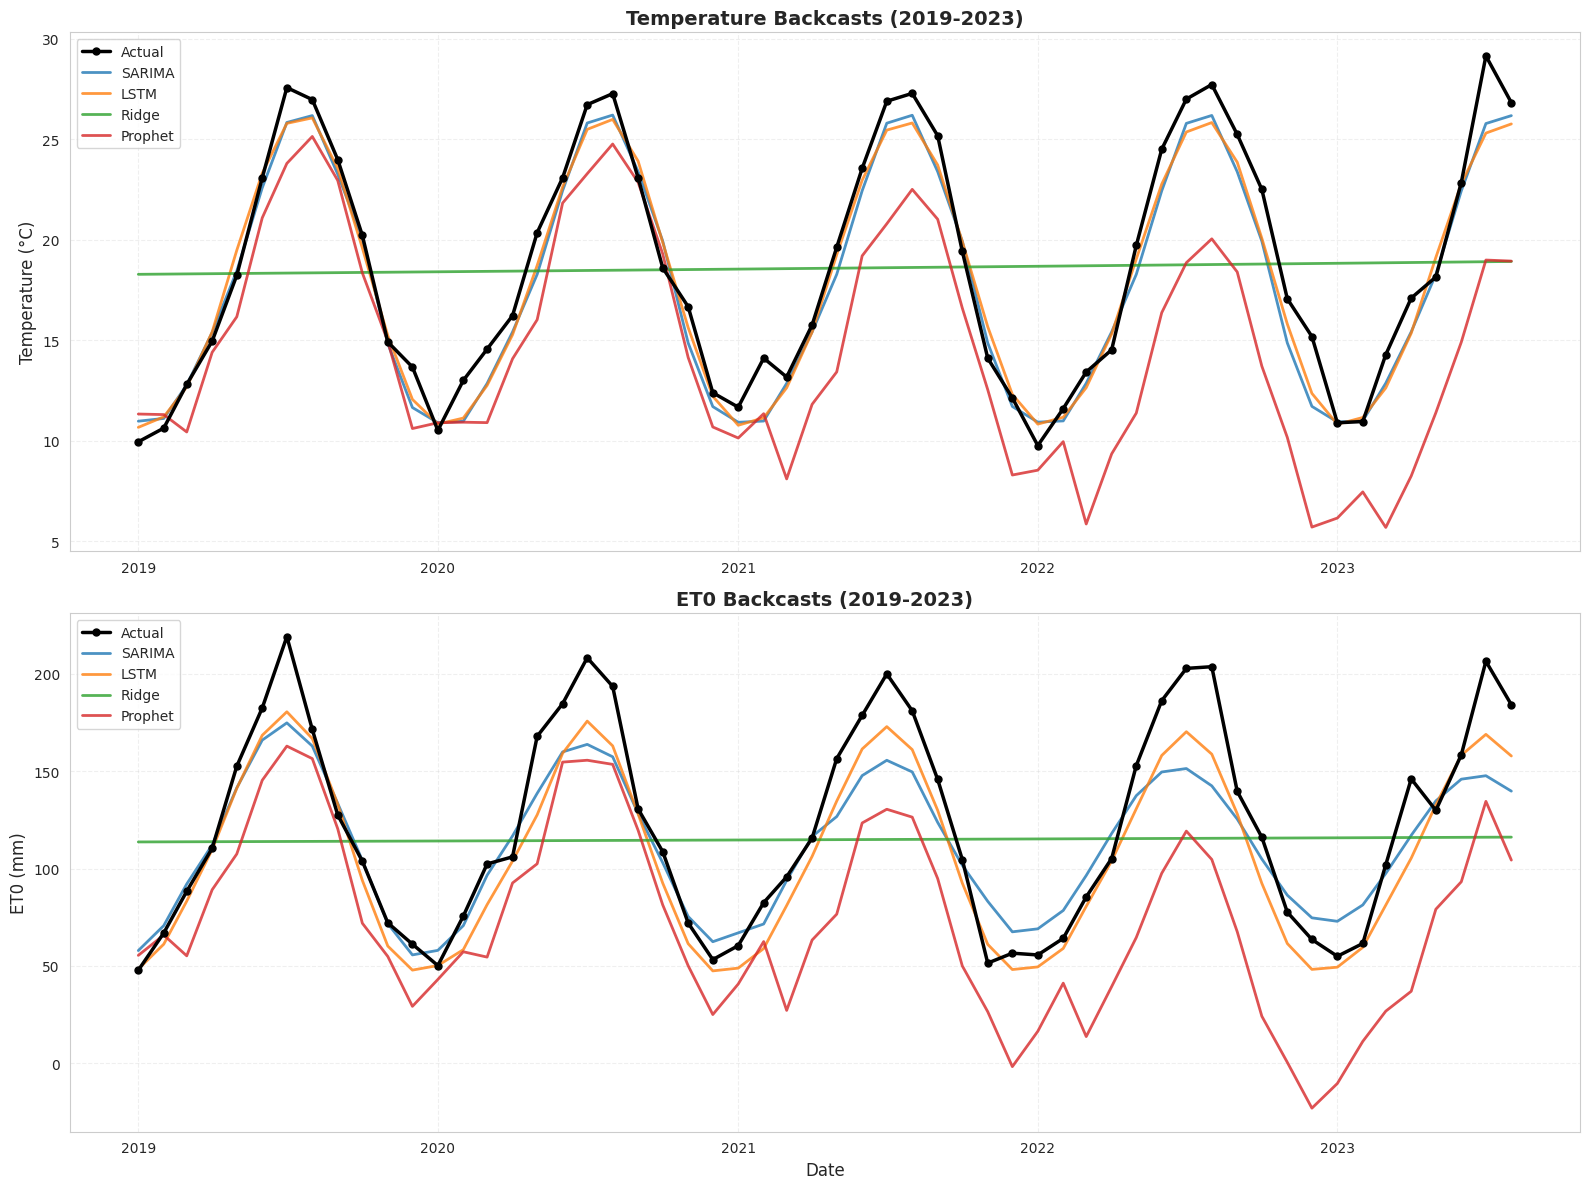

✅ Visualization saved: backcast_comparison_both_variables.png


In [9]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12))

# Temperature
ax1.plot(temp_results['Date'], temp_results['Actual'], 'ko-', label='Actual', linewidth=2.5, markersize=5, zorder=5)
ax1.plot(temp_results['Date'], temp_results['SARIMA'], label='SARIMA', alpha=0.8, linewidth=2)
ax1.plot(temp_results['Date'], temp_results['LSTM'], label='LSTM', alpha=0.8, linewidth=2)
ax1.plot(temp_results['Date'], temp_results['Ridge'], label='Ridge', alpha=0.8, linewidth=2)
ax1.plot(temp_results['Date'], temp_results['Prophet'], label='Prophet', alpha=0.8, linewidth=2)
ax1.set_title('Temperature Backcasts (2019-2023)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Temperature (°C)', fontsize=12)
ax1.legend(loc='best', fontsize=10)
ax1.grid(True, alpha=0.3, linestyle='--')

# ET0
ax2.plot(et0_results['Date'], et0_results['Actual'], 'ko-', label='Actual', linewidth=2.5, markersize=5, zorder=5)
ax2.plot(et0_results['Date'], et0_results['SARIMA'], label='SARIMA', alpha=0.8, linewidth=2)
ax2.plot(et0_results['Date'], et0_results['LSTM'], label='LSTM', alpha=0.8, linewidth=2)
ax2.plot(et0_results['Date'], et0_results['Ridge'], label='Ridge', alpha=0.8, linewidth=2)
ax2.plot(et0_results['Date'], et0_results['Prophet'], label='Prophet', alpha=0.8, linewidth=2)
ax2.set_title('ET0 Backcasts (2019-2023)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Date', fontsize=12)
ax2.set_ylabel('ET0 (mm)', fontsize=12)
ax2.legend(loc='best', fontsize=10)
ax2.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('backcast_comparison_both_variables.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Visualization saved: backcast_comparison_both_variables.png")

## 8. Download Files (Colab Only)

In [10]:
if IN_COLAB:
    from google.colab import files
    files.download('historical_backcasts_temperature_2019_2023_real.csv')
    files.download('historical_backcasts_et0_2019_2023_real.csv')
    files.download('backcast_comparison_both_variables.png')
    print("✅ All files ready for download!")
else:
    print("💻 Files saved locally!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ All files ready for download!


---

## ✅ Next Steps

1. Download both CSV files
2. Place in `RL Agent/` folder:
   - `historical_backcasts_temperature_2019_2023_real.csv`
   - `historical_backcasts_et0_2019_2023_real.csv`
3. Update `pretrain_agent.py` to train on appropriate variable
4. Run: `python pretrain_agent.py`
5. Run: `python rl_forecast_unified.py`